# REST API
- Representational State Transfer
- Client와 Server가 통신하기 위한 URL 구조에 대한 정의 및 디자인

## 1\. Kakao API

### 1-1. request token 얻기
- `https://developers.kakao.com/`
- 내 애플리케이션 > 애플리케이션 추가하기

### 1-2. KoGPT
- 문서 > KoGPT > REST API
- tokens : 공백을 제외한 글자수

#### 1. 다음문장 만들기

#### 2. 문장 분류하기
- 문장 마다 `=긍정`, `=부정` 문자열 작성
- 분류할 마지막 문장 `=` 문자열 작성

#### 3. 뉴스 한 줄 요약하기
- 마지막에 `한줄 요약:` 문자열 작성

#### 4. 질문에 답변하기
- 문장 마지막에 `?:` 로 끝남

#### 5. 응용하기

## 2\. Naver API
- 통합검색어 트렌드 API
    - https://datalab.naver.com/
    - https://datalab.naver.com/keyword/trendSearch.naver

In [8]:
import pandas as pd
import requests
import json

### 2-1. Request Token 얻기
- `https://developers.naver.com`
- 1. Request Token 얻기 : 애플리케이션등록 -> app_key 획득
- 2. app_key를 이용해서 데이터 가져오기

In [38]:
CLIENT_ID, CLIENT_SECRET = 'avTsvBkNUNdXTlwfJ7o4', 'KsRlnbcE5p'

### 2-2. 통합검색어 트렌드 API
- 서비스 : `https://datalab.naver.com/keyword/trendSearch.naver`
- 내 애플리케이션 > KT 애플리케이션 > API 설정 > 데이터랩(검색어 트렌드) 추가
- 사용법 : `https://developers.naver.com/docs/serviceapi/datalab/search/search.md#통합-검색어-트렌드`

In [40]:
# 1. URL
url = 'https://openapi.naver.com/v1/datalab/search'  # API를 얻은 사이트에 있던 url

In [56]:
# 2. request > response(json)

# Request Token 얻은 곳에서 지정해준 파라미터에 맞게 나의 정보 입력
# https://developers.naver.com/docs/serviceapi/datalab/search/search.md#%EB%84%A4%EC%9D%B4%EB%B2%84-%ED%86%B5%ED%95%A9-%EA%B2%80%EC%83%89%EC%96%B4-%ED%8A%B8%EB%A0%8C%EB%93%9C-%EC%A1%B0%ED%9A%8C
params = {
    'startDate': '2018-01-01',
    'endDate': '2023-12-31',
    'timeUnit': 'month',
    'keywordGroups': [
        {'groupName': '트위터', 'keywords':['트위터','트윗']},
        {'groupName': '페이스북', 'keywords':['페이스북','페북']},
        {'groupName': '인스타그램', 'keywords':['인스타그램','인스타']},
    ]
}

# header를 지정해주지 않고 그냥 파이썬으로 접근하면 접근거부 당함. -> header 지정 후 접근(request)해주기
# 위에서 얻은 Request Token 정보 입력해주기
headers = {
    'Content-Type': 'application/json',   # application/x-www-form-urlencoded; charset=UTF-8  -> 이렇게 쓰면 에러
    'X-Naver-Client-Id': CLIENT_ID,
    'X-Naver-Client-Secret': CLIENT_SECRET,
}

# 인터넷 상에서 데이터를 주고받을 때 한글을 사용할 수 없다. 한글이 깨져서 에러가 난다.  # data=params를 json.dumps(params)로 변경.
# 해당 사이트에서는 get방식이 아닌 post방식으로 request하기 때문에 "requests.post"
response = requests.post(url, data=json.dumps(params), headers=headers)
response

<Response [200]>

In [58]:
# 3. parsing
data= response.json()['results']
data

[{'title': '트위터',
  'keywords': ['트위터', '트윗'],
  'data': [{'period': '2018-01-01', 'ratio': 14.59502},
   {'period': '2018-02-01', 'ratio': 13.0238},
   {'period': '2018-03-01', 'ratio': 12.97953},
   {'period': '2018-04-01', 'ratio': 12.82991},
   {'period': '2018-05-01', 'ratio': 13.05391},
   {'period': '2018-06-01', 'ratio': 13.34512},
   {'period': '2018-07-01', 'ratio': 13.02773},
   {'period': '2018-08-01', 'ratio': 13.45399},
   {'period': '2018-09-01', 'ratio': 12.83755},
   {'period': '2018-10-01', 'ratio': 13.05677},
   {'period': '2018-11-01', 'ratio': 12.77338},
   {'period': '2018-12-01', 'ratio': 12.86931},
   {'period': '2019-01-01', 'ratio': 13.31172},
   {'period': '2019-02-01', 'ratio': 11.74776},
   {'period': '2019-03-01', 'ratio': 11.82313},
   {'period': '2019-04-01', 'ratio': 12.32991},
   {'period': '2019-05-01', 'ratio': 12.43771},
   {'period': '2019-06-01', 'ratio': 13.29913},
   {'period': '2019-07-01', 'ratio': 14.00593},
   {'period': '2019-08-01', 'ratio

In [60]:
# 4. preprocessing
dfs = []
for row in data:
    df = pd.DataFrame(row['data'])
    df['title'] = row['title']
    dfs.append(df)

In [68]:
dfs[2]

,period,ratio,title
0,2018-01-01,23.41982,인스타그램
1,2018-02-01,22.53544,인스타그램
2,2018-03-01,25.39880,인스타그램
3,2018-04-01,26.55983,인스타그램
4,2018-05-01,28.60035,인스타그램
...,...,...,...
67,2023-08-01,21.96847,인스타그램
68,2023-09-01,21.10131,인스타그램
69,2023-10-01,22.15029,인스타그램
70,2023-11-01,23.18797,인스타그램


In [62]:
# len(dfs), dfs[2]
result = pd.concat(dfs, ignore_index=True)
result.tail(2)

,period,ratio,title
214,2023-11-01,23.18797,인스타그램
215,2023-12-01,21.84237,인스타그램


In [64]:
pivot_df = result.pivot(index='period', columns='title', values='ratio')
pivot_df.tail(2)

title,인스타그램,트위터,페이스북
period,,,
2023-11-01,23.18797,22.86116,9.97093
2023-12-01,21.84237,23.01963,10.12856


C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47016 (\N{HANGUL SYLLABLE RAEM}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\Lib\sit

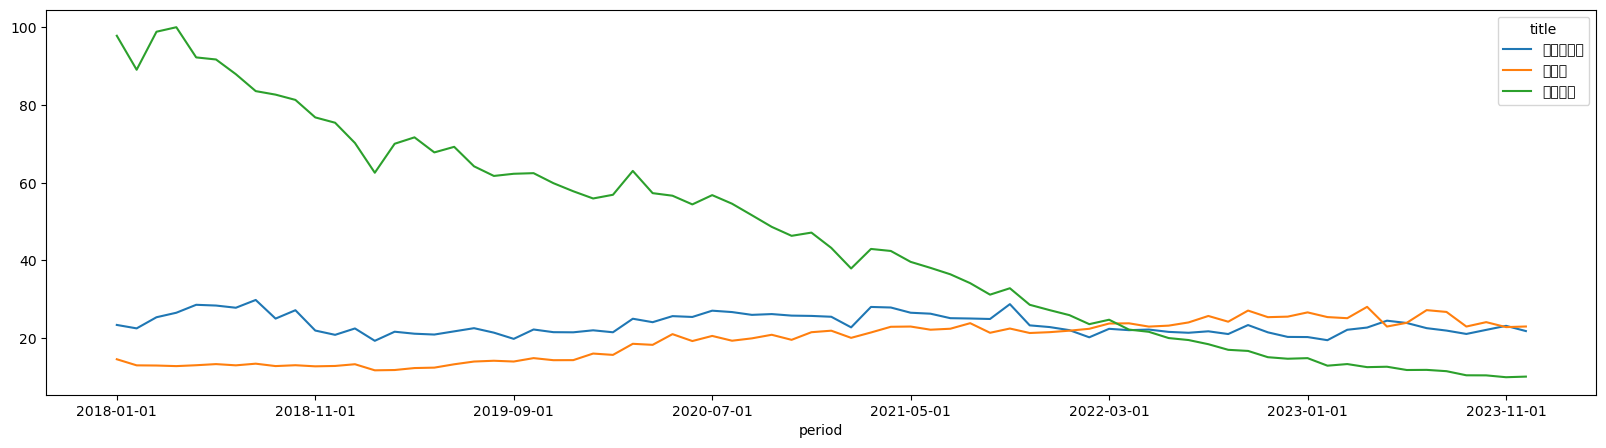

In [70]:
import matplotlib.pyplot as plt
pivot_df.plot(figsize=(20, 5))
plt.show()